In [ ]:
#putting everything (the basics in one)
import torch
from torch import nn
import matplotlib.pyplot as plt

In [ ]:
#create a device agnostic code-that uses gpu
device="cuda" if torch.cuda.is_available()else "cpu"
print(f'using {device}')

using cuda


In [ ]:
#preparing data:create some data with linear regression formula
weight=0.9
bias=0.3

start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias
X[:10],y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3180],
         [0.3360],
         [0.3540],
         [0.3720],
         [0.3900],
         [0.4080],
         [0.4260],
         [0.4440],
         [0.4620]]))

In [ ]:
#split data
train_split=int(0.8*len(X))
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)


(40, 40, 10, 10)

In [ ]:
#plot the data
def plot_prediction(train_data=X_train,
                    train_label=y_train,
                    test_data=X_test,
                    test_label=y_test,
                    predictions=None):
  #plots test and train data and compare prediction
  plt.figure(figsize=(10,7))
  plt.scatter(train_data,train_label,c="b", s=4,label="training data")

  plt.scatter(test_data,test_label,c="g",s=4,label="testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions,c="r",s=4 ,label="predictions")
  plt.legend(prop={"size":14});

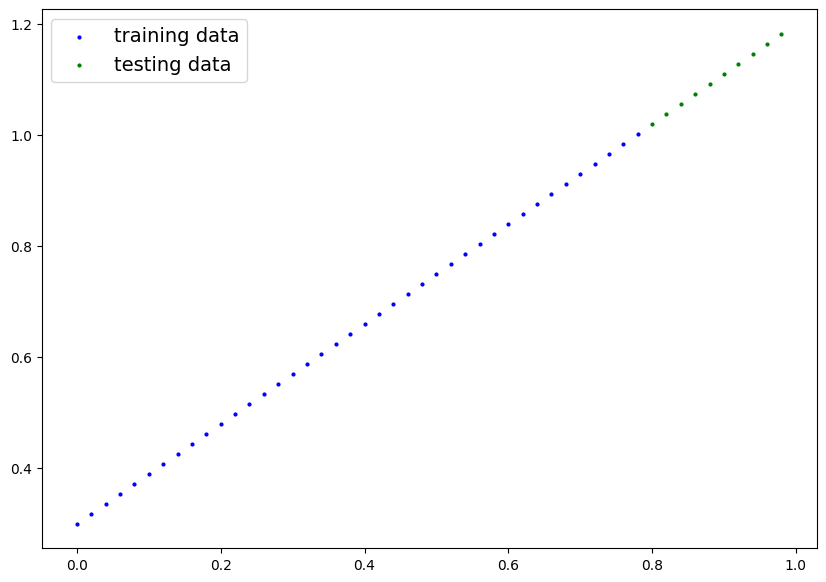

In [ ]:
plot_prediction(X_train,y_train,X_test,y_test)

In [ ]:
#building model
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    #use nn.linear() for creating ,odel parameters
    self.linear_layer=nn.Linear(in_features=1,
                                out_features=1)
  def forward(self,x:torch.Tensor) ->torch.Tensor:
    return self.linear_layer(x)
#set manaual seed
torch.manual_seed(42)
model_1=LinearRegressionModel()
model_1,model_1.state_dict()



(LinearRegressionModel(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
#set the model to use the target device
model_1.to(device)


LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
#Training

loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model_1.parameters(),lr=0.01 )

In [ ]:
#training loop
torch.manual_seed(42)
epochs=200
#put data on the target device
X_train =X_train.to(device)
y_train =y_train.to(device)
X_test =X_test.to(device)
y_test =y_test.to(device)
for epoch in range(epochs):
  model_1.train()
  y_pred=model_1(X_train)
  loss =loss_fn(y_pred,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  model_1.eval()
  with torch.inference_mode():
    test_pred=model_1(X_test)
    test_loss =loss_fn(test_pred, y_test)
  if epoch% 10==0:
    print(f'Epoch: {epoch} |Loss :{loss} |Test loss:{test_loss}')


Epoch: 0 |Loss :0.4771779179573059 |Test loss:0.3959762752056122
Epoch: 10 |Loss :0.3619680404663086 |Test loss:0.26126644015312195
Epoch: 20 |Loss :0.24675817787647247 |Test loss:0.1265566051006317
Epoch: 30 |Loss :0.13154831528663635 |Test loss:0.014028477482497692
Epoch: 40 |Loss :0.06491247564554214 |Test loss:0.09489572793245316
Epoch: 50 |Loss :0.05543327331542969 |Test loss:0.11483816057443619
Epoch: 60 |Loss :0.051387716084718704 |Test loss:0.114861860871315
Epoch: 70 |Loss :0.04785960912704468 |Test loss:0.11071059852838516
Epoch: 80 |Loss :0.04441455751657486 |Test loss:0.1031249389052391
Epoch: 90 |Loss :0.04097578674554825 |Test loss:0.09485241770744324
Epoch: 100 |Loss :0.037541069090366364 |Test loss:0.08726675063371658
Epoch: 110 |Loss :0.03411097452044487 |Test loss:0.07899420708417892
Epoch: 120 |Loss :0.030672166496515274 |Test loss:0.07072167843580246
Epoch: 130 |Loss :0.027239132672548294 |Test loss:0.0631360113620758
Epoch: 140 |Loss :0.023807354271411896 |Test los

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.8840]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3065], device='cuda:0'))])

In [ ]:
#making and evaluating predictions
model_1.eval()
with torch.inference_mode():
  y_preds=model_1(X_test)
y_preds

tensor([[1.0137],
        [1.0314],
        [1.0491],
        [1.0668],
        [1.0845],
        [1.1021],
        [1.1198],
        [1.1375],
        [1.1552],
        [1.1729]], device='cuda:0')

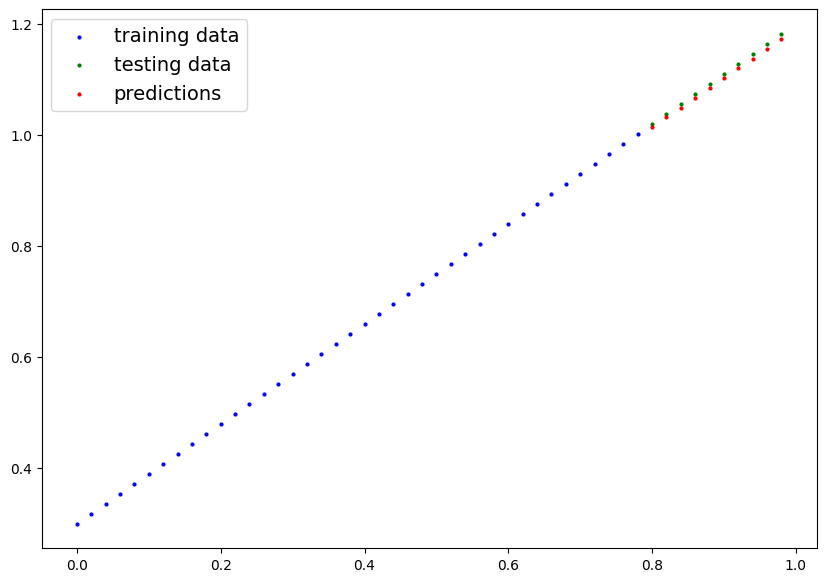

In [ ]:
plot_prediction(predictions=y_preds.cpu())